In [1]:
import sys
print(sys.executable)

/users/k21033112/venvs/tf-gpu/bin/python


In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import os
print(os.getcwd())

/cephfs/volumes/hpc_home/k21033112/df092fb9-9f5f-47af-ac37-1236e75d84de/ml-project/notebooks


In [4]:
path = "../data"

In [5]:
import os
NoImpairment = os.path.join(path,'NoImpairment/')
MildImpairment = os.path.join(path,'MildImpairment/')
ModerateImpairment = os.path.join(path,'ModerateImpairment/')
print("Number of images showing no impairment", len(os.listdir(NoImpairment)))
print("Number of images showing Mild Impairment", len(os.listdir(MildImpairment)))
print("Number of images showing Moderate Impairment", len(os.listdir(ModerateImpairment)))

Number of images showing no impairment 2560
Number of images showing Mild Impairment 1792
Number of images showing Moderate Impairment 724


In [6]:
NoImpairment_images =  os.listdir(NoImpairment)
MildImpairment_images =  os.listdir(MildImpairment) 
ModerateImpairment_images =  os.listdir(ModerateImpairment) 

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

path = "../data"
classes = ["NoImpairment", "MildImpairment", "ModerateImpairment"]

X = []
labels_text = []

for c in classes:
    folder = os.path.join(path, c)
    files = [f for f in os.listdir(folder) if not f.startswith(".")]
    for f in files:
        X.append(os.path.join(folder, f))
        labels_text.append(c)   # one label per image

X = np.array(X)
labels_text = np.array(labels_text)

le = LabelEncoder()
y = le.fit_transform(labels_text)  # y is now 0/1/2 for every image

print("Label mapping:", dict(zip(le.classes_, range(len(le.classes_)))))
print("Lengths:", len(X), len(y)) 

# Split 80/10/10 (stratified)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=18, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=18, stratify=y_temp
)

print("train/val/test:", len(X_train), len(X_val), len(X_test))
print("train counts:", np.bincount(y_train))
print("val counts:", np.bincount(y_val))
print("test counts:", np.bincount(y_test))


Label mapping: {np.str_('MildImpairment'): 0, np.str_('ModerateImpairment'): 1, np.str_('NoImpairment'): 2}
Lengths: 5076 5076
train/val/test: 4060 508 508
train counts: [1433  579 2048]
val counts: [179  73 256]
test counts: [180  72 256]


In [10]:
%pip install pillow

Note: you may need to restart the kernel to use updated packages.


In [11]:
from PIL import Image

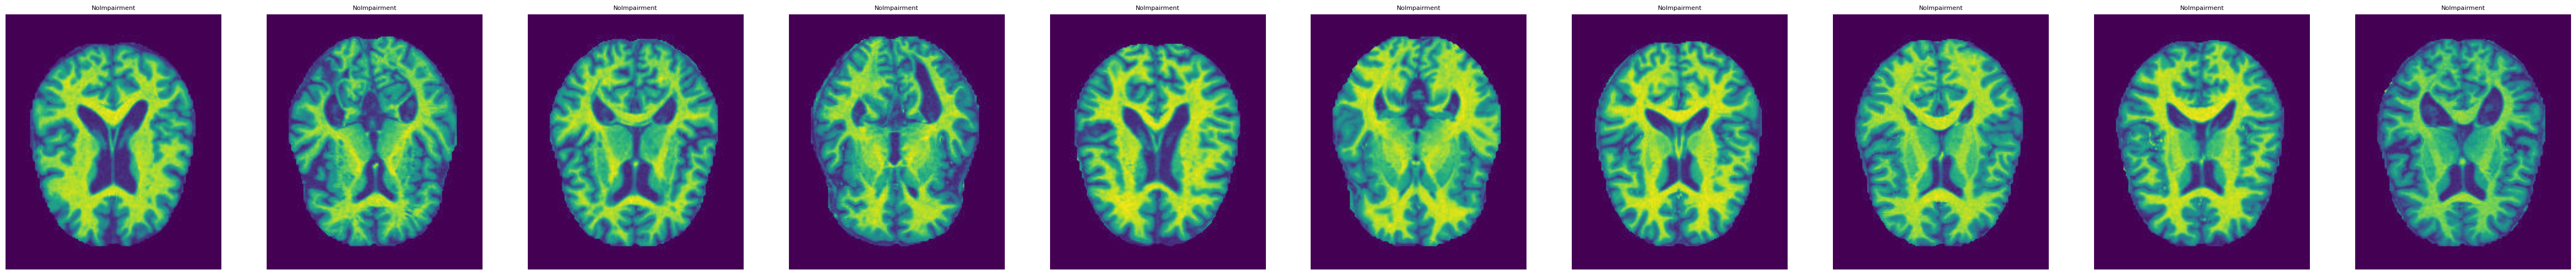

In [12]:
num_images = 10

plt.figure(figsize=(60, 6))
for i, image_name in enumerate(NoImpairment_images[:num_images]):
    img_path = os.path.join(NoImpairment, image_name)
    img = Image.open(img_path)
    plt.subplot(1, num_images, i+1)
    plt.imshow(img) 
    plt.title("NoImpairment", fontsize=8)
    plt.axis("off")
plt.show()

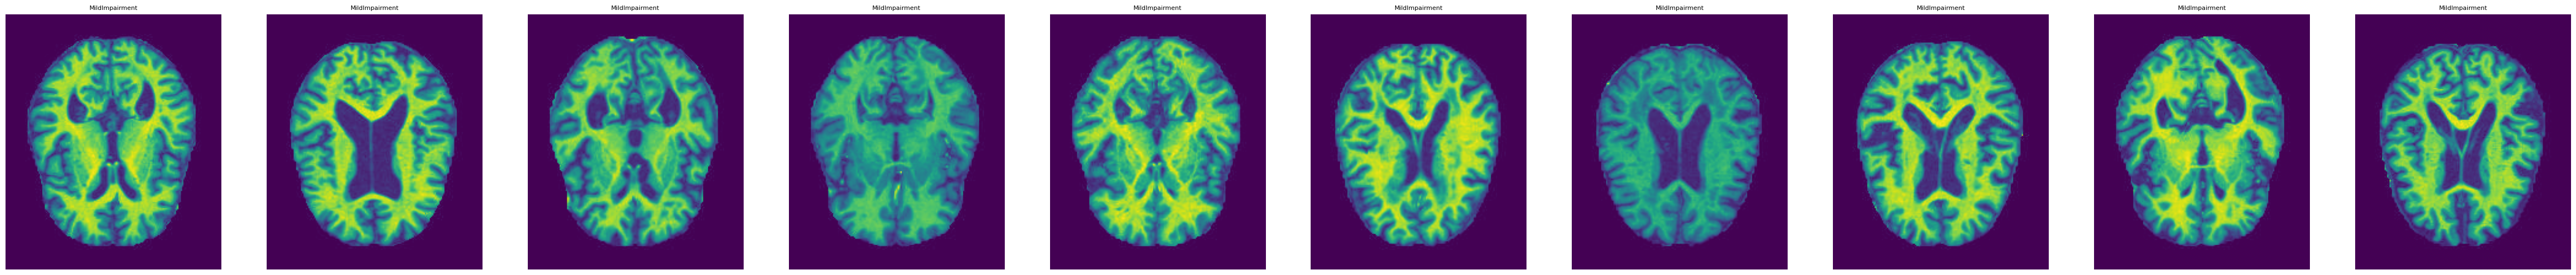

In [13]:
num_images = 10

plt.figure(figsize=(60, 6))
for i, image_name in enumerate(MildImpairment_images[:num_images]):
    img_path = os.path.join(MildImpairment, image_name)
    img = Image.open(img_path)
    plt.subplot(1, num_images, i+1)
    plt.imshow(img) 
    plt.title("MildImpairment", fontsize=8)
    plt.axis("off")
plt.show()

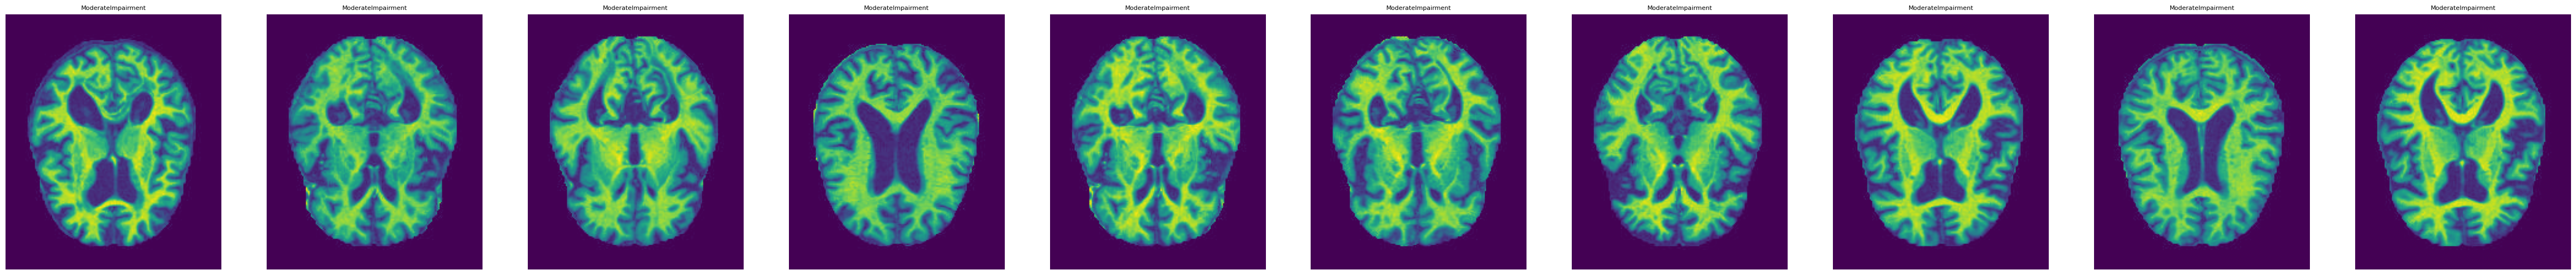

In [14]:
num_images = 10

plt.figure(figsize=(60, 6))
for i, image_name in enumerate(ModerateImpairment_images[:num_images]):
    img_path = os.path.join(ModerateImpairment, image_name)
    img = Image.open(img_path)
    plt.subplot(1, num_images, i+1)
    plt.imshow(img) 
    plt.title("ModerateImpairment", fontsize=8)
    plt.axis("off")
plt.show()

PIL type: <class 'PIL.JpegImagePlugin.JpegImageFile'>
NumPy shape: (208, 176)
dtype: uint8


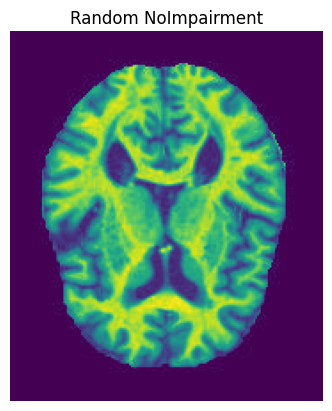

In [15]:
rand_image = np.random.randint(len(NoImpairment_images))
image_name = NoImpairment_images[rand_image]
img_path = os.path.join(NoImpairment, image_name)

img = Image.open(img_path)
img_np = np.array(img)

print("PIL type:", type(img))
print("NumPy shape:", img_np.shape)
print("dtype:", img_np.dtype)

plt.imshow(img)
plt.title("Random NoImpairment")
plt.axis("off")
plt.show()

PIL type: <class 'PIL.JpegImagePlugin.JpegImageFile'>
NumPy shape: (208, 176)
dtype: uint8


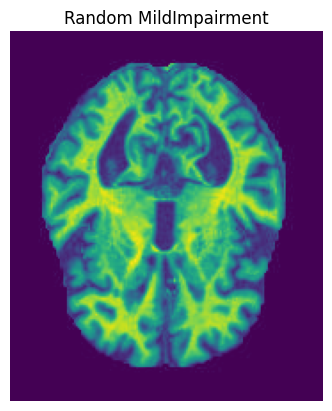

In [16]:
rand_image = np.random.randint(len(MildImpairment_images))
image_name = MildImpairment_images[rand_image]
img_path = os.path.join(MildImpairment, image_name)

img = Image.open(img_path)
img_np = np.array(img)

print("PIL type:", type(img))
print("NumPy shape:", img_np.shape)
print("dtype:", img_np.dtype)

plt.imshow(img)
plt.title("Random MildImpairment")
plt.axis("off")
plt.show()

PIL type: <class 'PIL.JpegImagePlugin.JpegImageFile'>
NumPy shape: (208, 176)
dtype: uint8


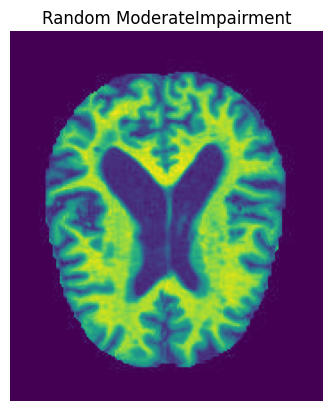

In [17]:
rand_image = np.random.randint(len(ModerateImpairment_images))
image_name = ModerateImpairment_images[rand_image]
img_path = os.path.join(ModerateImpairment, image_name)

img = Image.open(img_path)
img_np = np.array(img)

print("PIL type:", type(img))
print("NumPy shape:", img_np.shape)
print("dtype:", img_np.dtype)

plt.imshow(img)
plt.title("Random ModerateImpairment")
plt.axis("off")
plt.show()

In [18]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [19]:
import tensorflow as tf 
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom

data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.05), 
    RandomZoom(0.1)
])

2026-01-29 16:27:13.071885: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-29 16:27:13.121200: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-29 16:27:14.359376: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1769704034.990729 3406701 gpu_device.cc:2020] Created device /job:lo

In [20]:
img_size = (96, 96)
batch_size = 8
num_classes = 3

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=1)
    img = tf.image.resize(img, img_size)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label 

In [21]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds   = tf.data.Dataset.from_tensor_slices((X_val, y_val)).map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds  = tf.data.Dataset.from_tensor_slices((X_test, y_test)).map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

train_ds = train_ds.cache().shuffle(2000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [22]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Input(shape=(img_size[0], img_size[1], 1)),
    data_augmentation,

    Conv2D(16, 3, activation="relu"),
    MaxPooling2D(),

    Conv2D(32, 3, activation="relu"),
    MaxPooling2D(),

    Flatten(),
    Dense(32, activation="relu"),
    Dropout(0.3),

    Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 96, 96, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 94, 94, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15488)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       495,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,547 (1.91 MB)

 Trainable params: 500,547 (1.91 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = dict(zip(classes, weights))
class_weight

{np.int64(0): np.float64(0.9444056757385438),
 np.int64(1): np.float64(2.337363270005757),
 np.int64(2): np.float64(0.6608072916666666)}

In [24]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=[early_stopping],
    class_weight = class_weight
)

Epoch 1/20


2026-01-29 16:28:13.380636: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91801
Could not load symbol cuFuncGetName. Error: /lib/x86_64-linux-gnu/libcuda.so.1: undefined symbol: cuFuncGetName


508/508 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4153 - loss: 1.0673 - val_accuracy: 0.4547 - val_loss: 1.0283
Epoch 2/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4904 - loss: 0.9808 - val_accuracy: 0.4921 - val_loss: 0.9524
Epoch 3/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4995 - loss: 0.9468 - val_accuracy: 0.4921 - val_loss: 0.8996
Epoch 4/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4995 - loss: 0.9368 - val_accuracy: 0.4961 - val_loss: 0.9178
Epoch 5/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4961 - loss: 0.9241 - val_accuracy: 0.5098 - val_loss: 0.8605
Epoch 6/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4990 - loss: 0.9109 - val_accuracy: 0.5413 - val_loss: 0.8269
Epoch 7/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5096 - loss: 0.9069 - val_accuracy: 0.5335 - val_loss: 0.8440
Epoch 8/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5204 - loss: 0.8914 - val_accuracy: 0.5610 - val_

In [25]:
model.evaluate(test_ds)

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6496 - loss: 0.7291


[0.7290616631507874, 0.6496062874794006]

In [26]:
import numpy as np

y_pred_prob = model.predict(test_ds)         
y_pred = np.argmax(y_pred_prob, axis=1)       

print(y_pred_prob[0:1])
print(y_pred[0:25])

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
[[0.36061308 0.00561662 0.63377035]]
[2 1 1 0 2 2 2 2 1 0 2 0 0 1 1 1 1 2 0 1 0 2 2 2 1]


In [27]:
y_true = np.concatenate([y for x, y in test_ds], axis=0)

print(y_true[0:25])

[0 1 2 2 2 2 2 2 0 0 2 0 0 1 0 1 0 2 0 0 0 2 2 0 0]


2026-01-29 16:28:57.764072: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


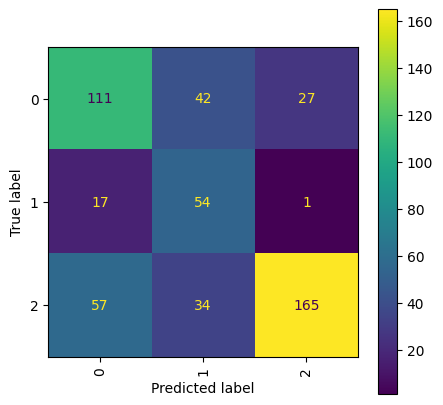

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(include_values=True, cmap="viridis", ax=ax, xticks_rotation="vertical")
plt.show()

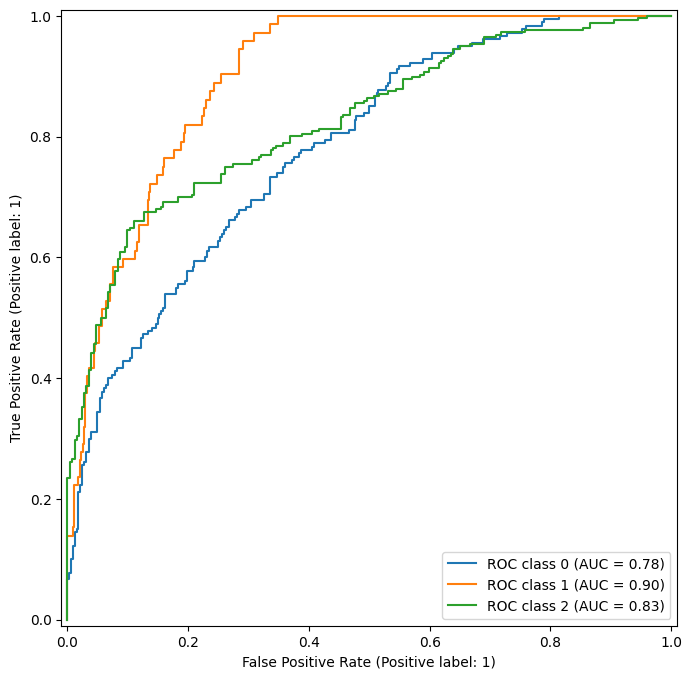

In [29]:
from sklearn.metrics import RocCurveDisplay
from sklearn.preprocessing import LabelBinarizer

label_binarizer = LabelBinarizer()
y_true_bin = label_binarizer.fit_transform(y_true)

n_classes = y_true_bin.shape[1]

fig, ax = plt.subplots(figsize=(8, 8))

for class_id in range(n_classes):
    RocCurveDisplay.from_predictions(
        y_true_bin[:, class_id],
        y_pred_prob[:, class_id],
        name=f"ROC class {class_id}",
        ax=ax,
    )

plt.show()

In [30]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_pred_prob = model.predict(test_ds)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.concatenate([y for x, y in test_ds], axis=0)

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, digits=3))

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
[[111  42  27]
 [ 17  54   1]
 [ 57  34 165]]
              precision    recall  f1-score   support

           0      0.600     0.617     0.608       180
           1      0.415     0.750     0.535        72
           2      0.855     0.645     0.735       256

    accuracy                          0.650       508
   macro avg      0.623     0.670     0.626       508
weighted avg      0.702     0.650     0.662       508



2026-01-29 16:29:06.226992: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [31]:
img_size = (224, 224)   
batch_size = 8          
num_classes = 3

def load_image_resnet(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=1)      
    img = tf.image.resize(img, img_size)
    img = tf.cast(img, tf.float32)

    img = tf.repeat(img, repeats=3, axis=-1)         
    img = tf.keras.applications.resnet50.preprocess_input(img) 
    return img, label


In [32]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).map(load_image_resnet, num_parallel_calls=tf.data.AUTOTUNE)
val_ds   = tf.data.Dataset.from_tensor_slices((X_val, y_val)).map(load_image_resnet, num_parallel_calls=tf.data.AUTOTUNE)
test_ds  = tf.data.Dataset.from_tensor_slices((X_test, y_test)).map(load_image_resnet, num_parallel_calls=tf.data.AUTOTUNE)

train_ds = train_ds.cache().shuffle(500).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [33]:
from tensorflow.keras import layers, Model

base = tf.keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=img_size + (3,)
)
base.trainable = False   

inputs = layers.Input(shape=img_size + (3,))
x = layers.RandomFlip("horizontal")(inputs)
x = layers.RandomRotation(0.05)(x)

x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │         6,147 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,593,859 (90.00 MB)

 Trainable params: 6,147 (24.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [36]:
early_stopping = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping]
)

model.evaluate(test_ds)

Epoch 1/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.6372 - loss: 0.7681 - val_accuracy: 0.6260 - val_loss: 0.7616
Epoch 2/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.6357 - loss: 0.7587 - val_accuracy: 0.6516 - val_loss: 0.7346
Epoch 3/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.6510 - loss: 0.7551 - val_accuracy: 0.6594 - val_loss: 0.7362
Epoch 4/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.6448 - loss: 0.7452 - val_accuracy: 0.6358 - val_loss: 0.7474
Epoch 5/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.6515 - loss: 0.7369 - val_accuracy: 0.6417 - val_loss: 0.7677
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6654 - loss: 0.7137


[0.7136979699134827, 0.665354311466217]

In [37]:
y_pred_prob = model.predict(test_ds)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.concatenate([y for x, y in test_ds], axis=0)

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, digits=3))

64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
[[ 90  10  80]
 [ 24  29  19]
 [ 26  11 219]]
              precision    recall  f1-score   support

           0      0.643     0.500     0.562       180
           1      0.580     0.403     0.475        72
           2      0.689     0.855     0.763       256

    accuracy                          0.665       508
   macro avg      0.637     0.586     0.600       508
weighted avg      0.657     0.665     0.651       508



2026-01-29 16:32:43.622724: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [38]:
base = tf.keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=img_size + (3,)
)
base.trainable = False

inputs = layers.Input(shape=img_size + (3,))
x = layers.RandomFlip("horizontal")(inputs)
x = layers.RandomRotation(0.05)(x)

x = tf.keras.applications.resnet.preprocess_input(x)

x = base(x, training=False)  
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [39]:
early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=[early_stopping]
)

model.evaluate(test_ds)

Epoch 1/8
508/508 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.4874 - loss: 1.1262 - val_accuracy: 0.5669 - val_loss: 0.8680
Epoch 2/8
508/508 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.5310 - loss: 0.9767 - val_accuracy: 0.5925 - val_loss: 0.8229
Epoch 3/8
508/508 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.5611 - loss: 0.9059 - val_accuracy: 0.5984 - val_loss: 0.8205
Epoch 4/8
508/508 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.5830 - loss: 0.8764 - val_accuracy: 0.6181 - val_loss: 0.7852
Epoch 5/8
508/508 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.5869 - loss: 0.8546 - val_accuracy: 0.6437 - val_loss: 0.7774
Epoch 6/8
508/508 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.5988 - loss: 0.8460 - val_accuracy: 0.6339 - val_loss: 0.7706
Epoch 7/8
508/508 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.6067 - loss: 0.8187 - val_accuracy: 0.6063 - val_loss: 0.8329
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6752 - loss: 0.7642


[0.7642272710800171, 0.6751968264579773]

In [41]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

base.trainable = True

for layer in base.layers[:120]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

total = 2560 + 1792 + 724
num_classes = 3
class_weights = {
    0: total / (num_classes * 2560),  
    1: total / (num_classes * 1792),  
    2: total / (num_classes * 724),   
}

early_stopping_ft = EarlyStopping(
    monitor="val_accuracy",
    patience=4,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [42]:
history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping_ft, reduce_lr],
    class_weight=class_weights
)

model.evaluate(test_ds)

Epoch 1/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 23s 28ms/step - accuracy: 0.5709 - loss: 0.9372 - val_accuracy: 0.6142 - val_loss: 0.8042 - learning_rate: 1.0000e-05
Epoch 2/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.6145 - loss: 0.8006 - val_accuracy: 0.6654 - val_loss: 0.6919 - learning_rate: 1.0000e-05
Epoch 3/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.6754 - loss: 0.6836 - val_accuracy: 0.7382 - val_loss: 0.5977 - learning_rate: 1.0000e-05
Epoch 4/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.7268 - loss: 0.5890 - val_accuracy: 0.7638 - val_loss: 0.5692 - learning_rate: 1.0000e-05
Epoch 5/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.7645 - loss: 0.5132 - val_accuracy: 0.8110 - val_loss: 0.4345 - learning_rate: 1.0000e-05
Epoch 6/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.8064 - loss: 0.4288 - val_accuracy: 0.8091 - val_loss: 0.4813 - learning_rate: 1.0000e-05
Epoch 7/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/ste

[0.2911292314529419, 0.8917322754859924]

In [43]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)

y_prob = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

In [44]:
acc = accuracy_score(y_true, y_pred)
print(f"Test accuracy: {acc:.3f}")

Test accuracy: 0.892


In [45]:
target_names = ["No impairment", "Mild impairment", "Moderate impairment"]  
print(classification_report(y_true, y_pred, target_names=target_names, digits=3))

                     precision    recall  f1-score   support

      No impairment      0.941     0.794     0.861       180
    Mild impairment      0.922     0.819     0.868        72
Moderate impairment      0.860     0.980     0.916       256

           accuracy                          0.892       508
          macro avg      0.907     0.865     0.882       508
       weighted avg      0.897     0.892     0.890       508



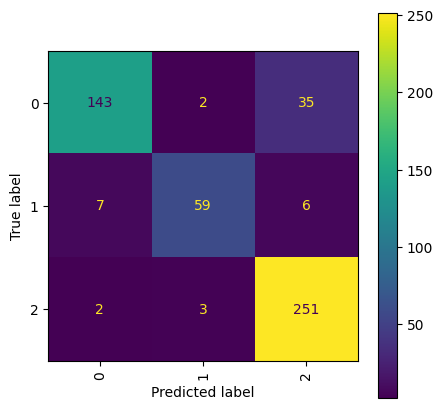

In [47]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(include_values=True, cmap="viridis", ax=ax, xticks_rotation="vertical")
plt.show()

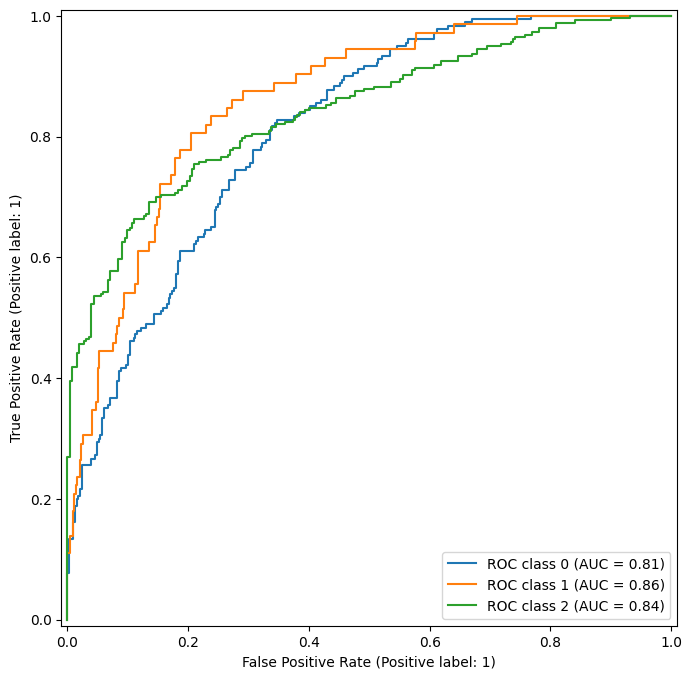

In [49]:
label_binarizer = LabelBinarizer()
y_true_bin = label_binarizer.fit_transform(y_true)

n_classes = y_true_bin.shape[1]

fig, ax = plt.subplots(figsize=(8, 8))

for class_id in range(n_classes):
    RocCurveDisplay.from_predictions(
        y_true_bin[:, class_id],
        y_pred_prob[:, class_id],
        name=f"ROC class {class_id}",
        ax=ax,
    )

plt.show()